<a href="https://colab.research.google.com/github/dking2023/DS-Final-Project---Logan-Amaya-Daylon/blob/main/CSE40467_Project_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Preprocessing Data

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

# Load data
df = pd.read_csv("athlete_events.csv")

# Drop columns not useful for clustering
cols_to_drop = ["Event", "ID", "Name", "Games", "Medal"]
df = df.drop(columns=cols_to_drop, errors="ignore")

#only include sports in the 2028 olmpyics (excluding athletics because it dominated dataset)
summer28_sports = [
    "3x3 Basketball",
    "Archery",
    "Artistic Gymnastics",
    "Artistic Swimming",
    "Badminton",
    "Baseball",
    "Basketball",
    "Beach Volleyball",
    "BMX Freestyle",
    "BMX Racing",
    "Boxing",
    "Canoe Slalom",
    "Canoe Sprint",
    "Climbing",
    "Cricket",
    "Cycling Road",
    "Cycling Track",
    "Diving",
    "Equestrian",
    "Fencing",
    "Flag Football",
    "Football (Soccer)",
    "Golf",
    "Handball",
    "Hockey",
    "Judo",
    "Lacrosse",
    "Modern Pentathlon",
    "Mountain Bike",
    "Open Water Swimming",
    "Rhythmic Gymnastics",
    "Rowing",
    "Rowing Coastal Beach Sprints",
    "Rugby Sevens",
    "Sailing",
    "Shooting",
    "Skateboarding",
    "Softball",
    "Squash",
    "Surfing",
    "Swimming",
    "Table Tennis",
    "Taekwondo",
    "Tennis",
    "Trampoline Gymnastics",
    "Triathlon",
    "Volleyball",
    "Water Polo",
    "Weightlifting",
    "Wrestling"
]
print("Original dataframe shape:", df.shape)
df = df[df['Sport'].isin(summer28_sports)].copy()


# Drop duplicate rows
df = df.drop_duplicates()

# Drop rows with missing values in important numeric columns
critical_numeric = ["Age", "Height", "Weight"]
df = df.dropna(subset=critical_numeric)

# Define numeric and categorical columns
numeric_features = ["Age", "Height", "Weight"]
categorical_features = ["Sex", "Sport"]

# Keep only the columns we want
selected_columns = numeric_features + categorical_features
df = df[selected_columns].copy()

counts = df['Sport'].value_counts()
reliable_sports = counts[counts >= 100].index
df_filtered = df[df['Sport'].isin(reliable_sports)]
#balance data to cap at 500 per sport
n_cap = 500

df = df_filtered.groupby('Sport', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), n_cap), random_state=42)
)


# Preprocessing pipeline
#  - scale numeric columns
#  - one-hot encode categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Transform the data
X_processed = preprocessor.fit_transform(df)

print("Cleaned dataframe shape:", df.shape)
print("Processed feature matrix shape:", X_processed.shape)

# Reduce dimensionality for clustering
svd = TruncatedSVD(n_components=30, random_state=42)
X_reduced = svd.fit_transform(X_processed)

print("Reduced feature matrix shape:", X_reduced.shape)

Original dataframe shape: (271116, 10)
Cleaned dataframe shape: (13342, 5)
Processed feature matrix shape: (13342, 33)
Reduced feature matrix shape: (13342, 30)


In [ ]:
df.head()

,Age,Height,Weight,Sex,Sport
94032,24.0,175.0,74.0,M,Archery
62868,31.0,194.0,115.0,M,Archery
74243,31.0,174.0,89.0,M,Archery
140189,25.0,161.0,58.0,F,Archery
24993,20.0,164.0,56.0,F,Archery


In [ ]:
df.describe()

,Age,Height,Weight
count,13342.000000,13342.000000,13342.000000
mean,25.692175,176.799655,72.788637
std,5.298728,10.918192,15.692646
min,11.000000,130.000000,28.000000
25%,22.000000,169.000000,62.000000
50%,25.000000,176.000000,71.000000
75%,29.000000,184.000000,82.000000
max,66.000000,223.000000,170.000000


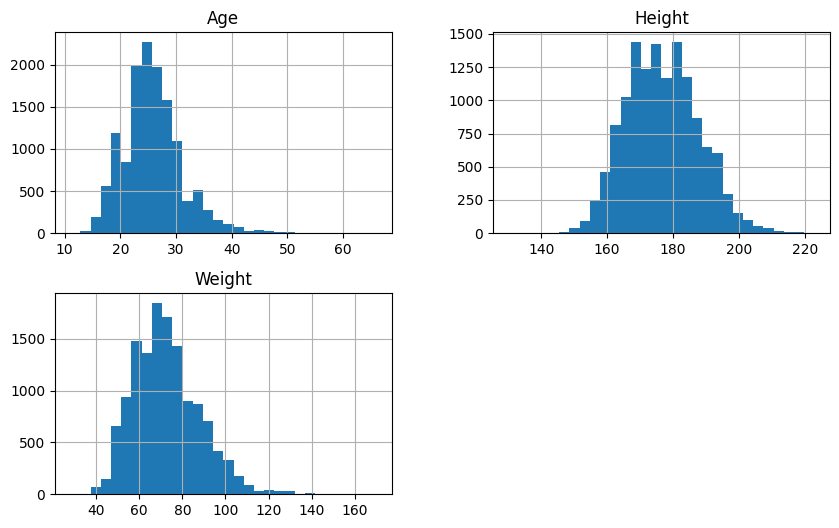


Number of duplicate rows: 497


In [ ]:
# CHECKING IF DATA IS VALID

import matplotlib.pyplot as plt
# Check for outliers
df[["Age", "Height", "Weight"]].hist(bins=30, figsize=(10, 6))
plt.show()
# Check for duplicates
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)



Feature Units and Descriptions:
*   Age: Years
*   Height: Centimeters
*   Weight: Kilograms


Running K-Means Clustering

To improve clustering performance, male and female athletes were analyzed separately since differences in height and weight would otherwise dominate the results. Irrelevant and redundant columns were removed to reduce noise, and the “Season” column was dropped because only summer sports were used. Key features such as age, height, weight, sport, and NOC were retained.

Outliers were removed using the IQR method, and categorical variables were one-hot encoded. Since this increased dimensionality, Truncated SVD was applied to reduce the data to 15 components while preserving important patterns.

The number of clusters was chosen using the elbow method. Although silhouette scores were higher for fewer clusters, the elbow graph showed diminishing returns at K = 4, so four clusters were selected to balance performance and interpretability.

Male processed shape: (8335, 29)
Male reduced shape: (8335, 15)
[Male] K = 2
[Male] Silhouette Score = 0.2617
[Male] Inertia = 20789.2758
----------------------------------------
[Male] K = 3
[Male] Silhouette Score = 0.2513
[Male] Inertia = 16849.6037
----------------------------------------
[Male] K = 4
[Male] Silhouette Score = 0.2125
[Male] Inertia = 14441.2107
----------------------------------------
[Male] K = 5
[Male] Silhouette Score = 0.1967
[Male] Inertia = 13252.7837
----------------------------------------


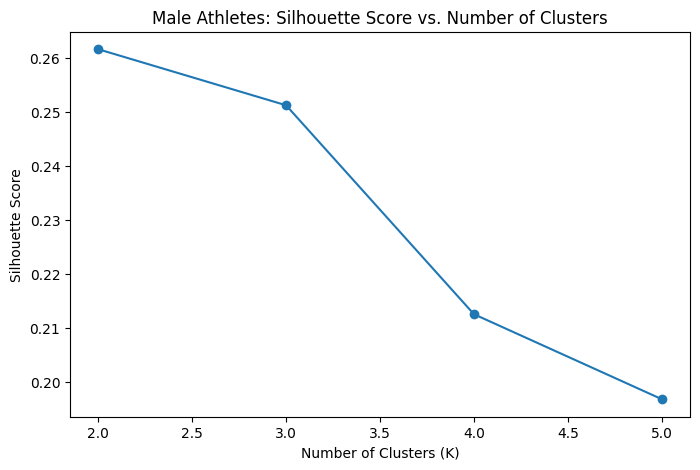

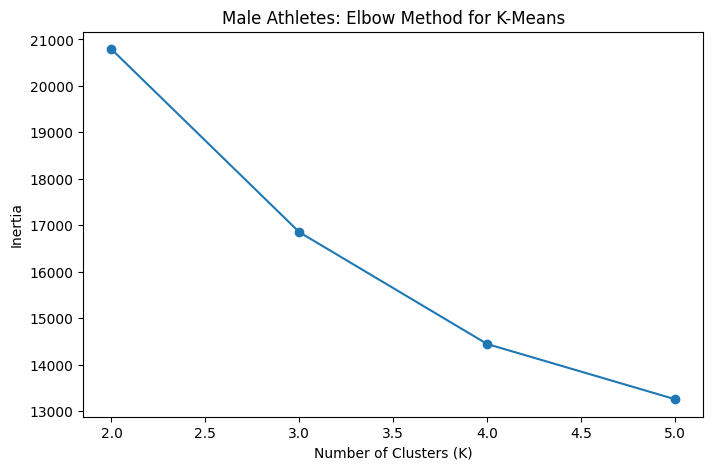

Final K chosen for male athletes based on elbow method: 3
Male cluster centers shape: (3, 15)

=== Male Cluster Sizes ===
Cluster
0    3117
1    3545
2    1673
Name: count, dtype: int64

=== Male Cluster Means (Numeric Features) ===
               Age      Height     Weight
Cluster                                  
0        25.239974  190.078922  92.010908
1        23.802257  173.387306  68.464316
2        33.611476  179.560072  78.335326

=== Male Cluster Std Dev (Numeric Features) ===
              Age    Height     Weight
Cluster                               
0        3.507579  7.122768  12.323733
1        3.237338  7.235970   8.465843
2        4.976347  6.726021   9.282672

=== Male Top Sports per Cluster ===

Male Cluster 0:
Sport
Basketball          277
Water Polo          271
Baseball            266
Rowing              259
Handball            249
Volleyball          229
Beach Volleyball    178
Weightlifting       137
Judo                136
Swimming            136
Name: count, 

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------
# Make a fresh copy and keep only MALE athletes
# -----------------------------
df_male = df.copy()
df_male = df_male[df_male["Sex"] == "M"].copy()


# -----------------------------
# Use feature set for clustering
# Sex is no longer needed because this dataset is only male
# -----------------------------
numeric_features_male = ["Age", "Height", "Weight"]
categorical_features_male = ["Sport"]

df_male = df_male[numeric_features_male + categorical_features_male].copy()

# -----------------------------
# Preprocess
# -----------------------------
preprocessor_male = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_male),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_male)
    ]
)

X_processed_male = preprocessor_male.fit_transform(df_male)

print("Male processed shape:", X_processed_male.shape)

# -----------------------------
# Dimensionality reduction
# -----------------------------
svd_male = TruncatedSVD(n_components=15, random_state=42)
X_reduced_male = svd_male.fit_transform(X_processed_male)

print("Male reduced shape:", X_reduced_male.shape)

# -----------------------------
# Try several K values
# -----------------------------
k_values = range(2, 6)
silhouette_scores_male = []
inertias_male = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    cluster_labels = kmeans.fit_predict(X_reduced_male)

    silhouette_avg = silhouette_score(
        X_reduced_male,
        cluster_labels,
        sample_size=min(10000, len(df_male)),
        random_state=42
    )

    silhouette_scores_male.append(silhouette_avg)
    inertias_male.append(kmeans.inertia_)

    print(f"[Male] K = {k}")
    print(f"[Male] Silhouette Score = {silhouette_avg:.4f}")
    print(f"[Male] Inertia = {kmeans.inertia_:.4f}")
    print("-" * 40)

# -----------------------------
# Plot silhouette score
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouette_scores_male, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Male Athletes: Silhouette Score vs. Number of Clusters")
plt.show()

# -----------------------------
# Plot elbow method
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias_male, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Male Athletes: Elbow Method for K-Means")
plt.show()

# -----------------------------
# Force final K = 3 based on elbow method
# -----------------------------
best_k_male = 3
print(f"Final K chosen for male athletes based on elbow method: {best_k_male}")

# -----------------------------
# Fit final K-Means
# -----------------------------
kmeans_final_male = KMeans(n_clusters=best_k_male, random_state=42, n_init=20)
final_labels_male = kmeans_final_male.fit_predict(X_reduced_male)

df_male["Cluster"] = final_labels_male

# -----------------------------
# Results
# -----------------------------
print("Male cluster centers shape:", kmeans_final_male.cluster_centers_.shape)

print("\n=== Male Cluster Sizes ===")
print(df_male["Cluster"].value_counts().sort_index())

print("\n=== Male Cluster Means (Numeric Features) ===")
print(df_male.groupby("Cluster")[["Age", "Height", "Weight"]].mean())

print("\n=== Male Cluster Std Dev (Numeric Features) ===")
print(df_male.groupby("Cluster")[["Age", "Height", "Weight"]].std())

print("\n=== Male Top Sports per Cluster ===")
for cluster in sorted(df_male["Cluster"].unique()):
    print(f"\nMale Cluster {cluster}:")
    print(df_male[df_male["Cluster"] == cluster]["Sport"].value_counts().head(10))


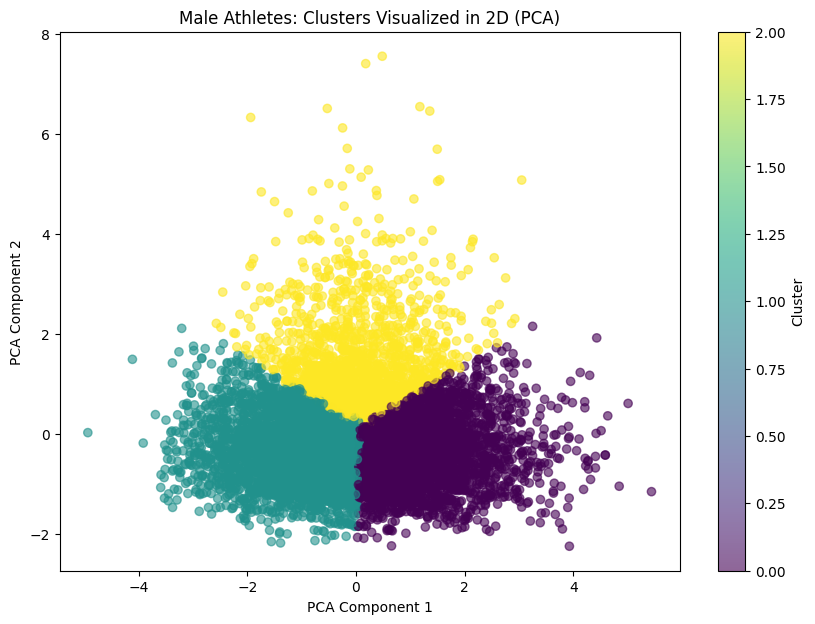

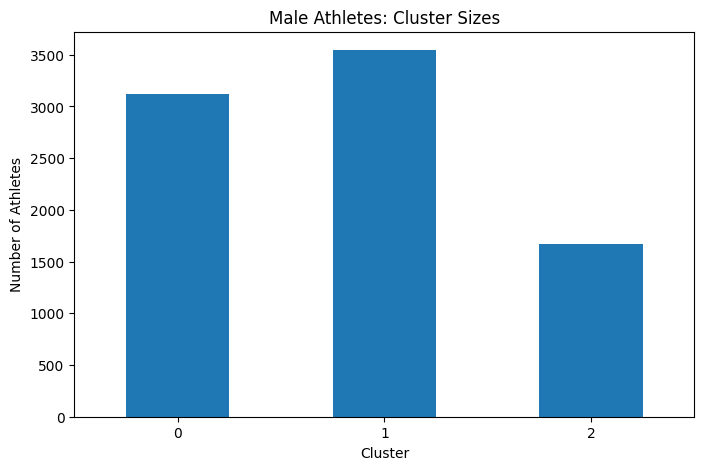

<Figure size 800x500 with 0 Axes>

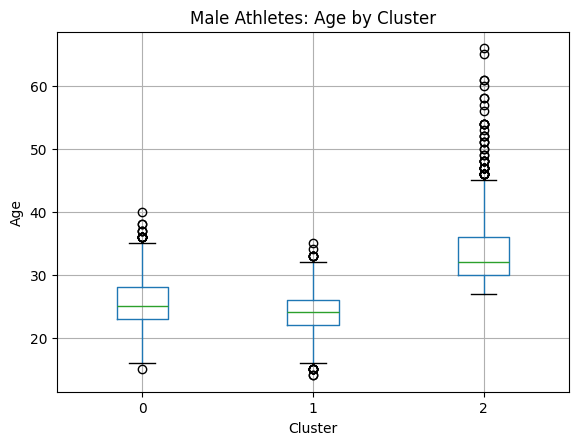

<Figure size 800x500 with 0 Axes>

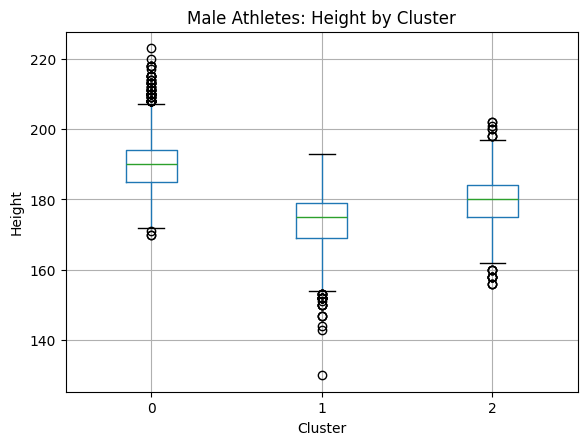

<Figure size 800x500 with 0 Axes>

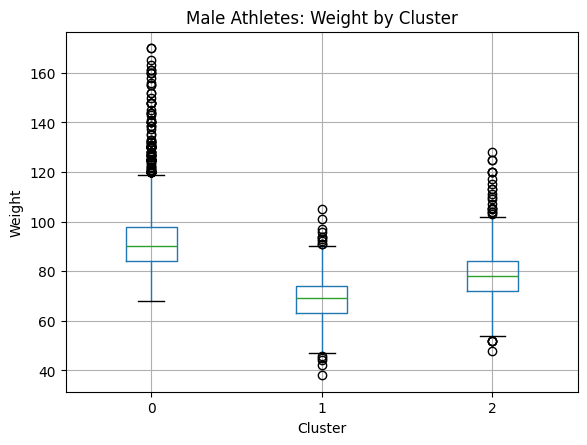

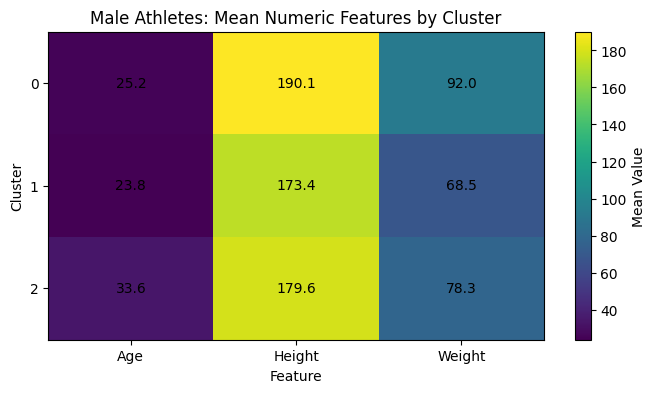

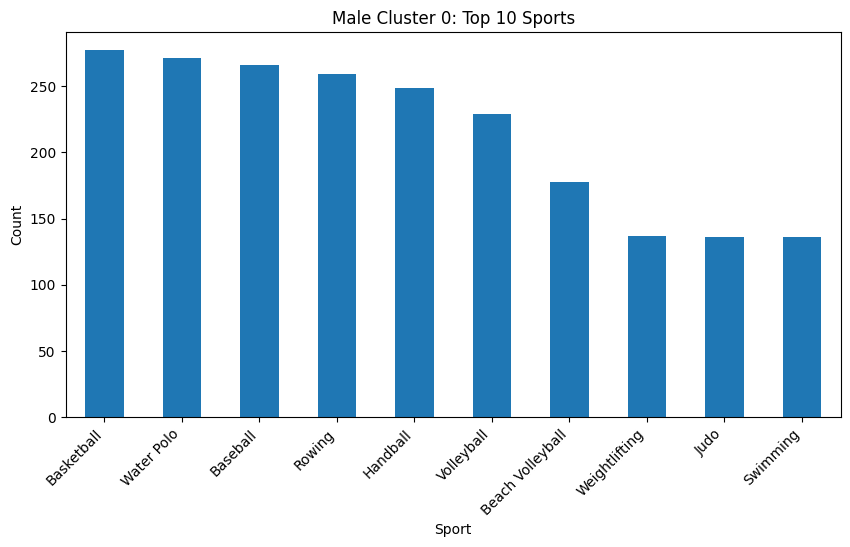

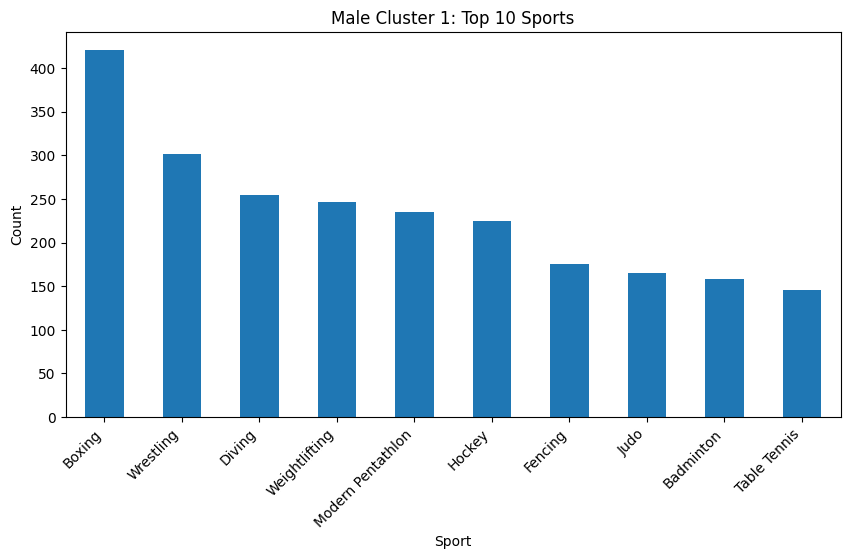

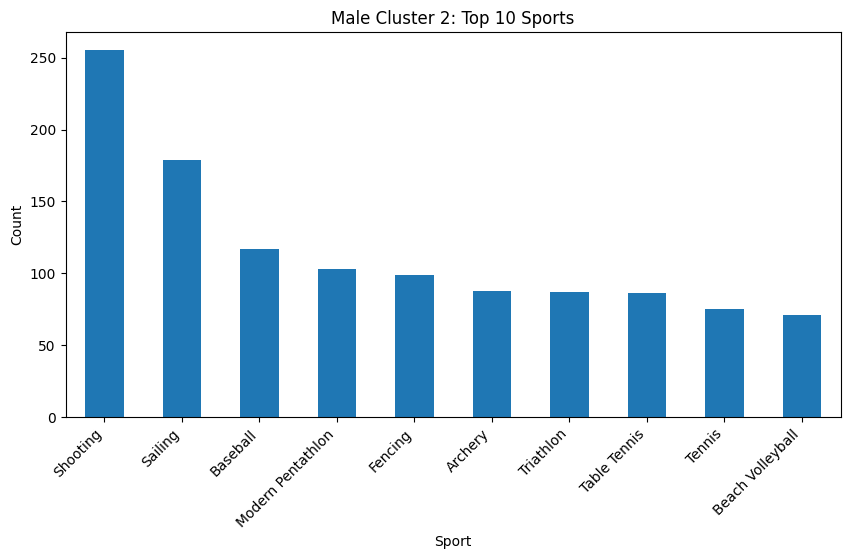

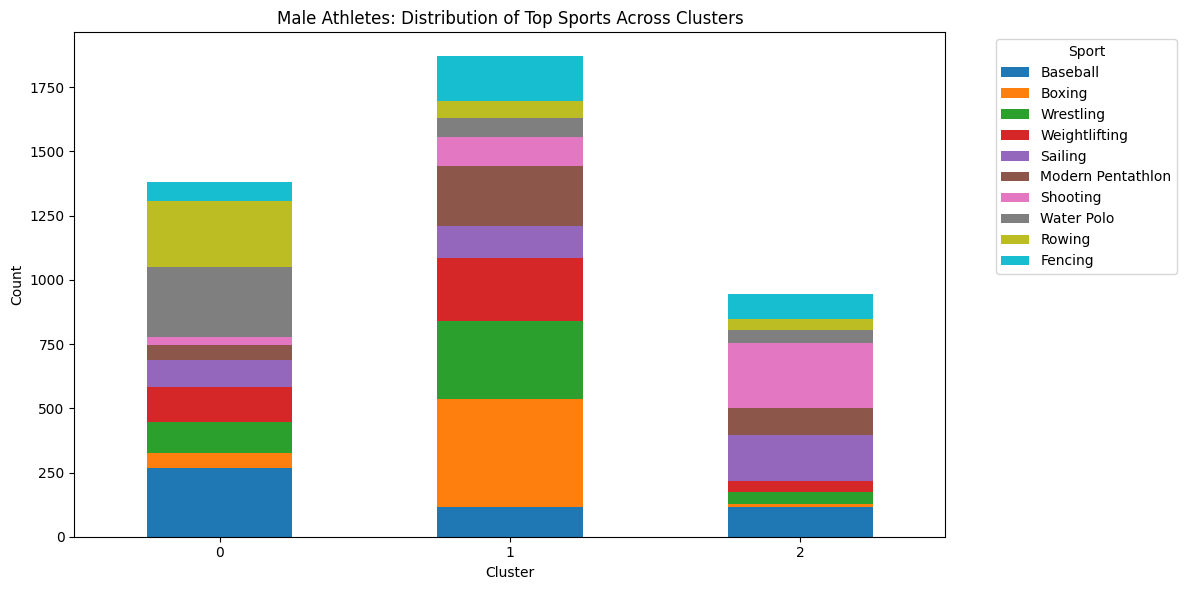

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------
# 1. PCA scatter plot of clusters
# -----------------------------
pca_male = PCA(n_components=2, random_state=42)
X_pca_male = pca_male.fit_transform(X_reduced_male)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca_male[:, 0],
    X_pca_male[:, 1],
    c=df_male["Cluster"],
    alpha=0.6
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Male Athletes: Clusters Visualized in 2D (PCA)")
plt.colorbar(scatter, label="Cluster")
plt.show()


# -----------------------------
# 2. Cluster size bar chart
# -----------------------------
cluster_counts_male = df_male["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
cluster_counts_male.plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Number of Athletes")
plt.title("Male Athletes: Cluster Sizes")
plt.xticks(rotation=0)
plt.show()


# -----------------------------
# 3. Boxplots for numeric features by cluster
# -----------------------------
numeric_cols = ["Age", "Height", "Weight"]

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    df_male.boxplot(column=col, by="Cluster")
    plt.title(f"Male Athletes: {col} by Cluster")
    plt.suptitle("")  # removes automatic pandas subtitle
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.show()


# -----------------------------
# 4. Heatmap of cluster means
# -----------------------------
cluster_means_male = df_male.groupby("Cluster")[["Age", "Height", "Weight"]].mean()

plt.figure(figsize=(8, 4))
plt.imshow(cluster_means_male, aspect="auto")
plt.colorbar(label="Mean Value")
plt.xticks(range(len(cluster_means_male.columns)), cluster_means_male.columns)
plt.yticks(range(len(cluster_means_male.index)), cluster_means_male.index)
plt.title("Male Athletes: Mean Numeric Features by Cluster")

# annotate values
for i in range(cluster_means_male.shape[0]):
    for j in range(cluster_means_male.shape[1]):
        plt.text(j, i, f"{cluster_means_male.iloc[i, j]:.1f}",
                 ha="center", va="center")

plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.show()


# -----------------------------
# 5. Top sports in each cluster (bar charts)
# -----------------------------
for cluster in sorted(df_male["Cluster"].unique()):
    top_sports = (
        df_male[df_male["Cluster"] == cluster]["Sport"]
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(10, 5))
    top_sports.plot(kind="bar")
    plt.title(f"Male Cluster {cluster}: Top 10 Sports")
    plt.xlabel("Sport")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.show()


# -----------------------------
# 6. Stacked bar chart of top sports across clusters
# -----------------------------
top_sports_overall = df_male["Sport"].value_counts().head(10).index

sport_cluster_table = pd.crosstab(
    df_male["Cluster"],
    df_male["Sport"]
)[top_sports_overall]

sport_cluster_table.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)
plt.title("Male Athletes: Distribution of Top Sports Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Sport", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Female shape (Athletics INCLUDED): (5007, 5)
Female shape after outlier removal: (4815, 5)
Female processed shape: (4815, 30)
Female reduced shape: (4815, 15)
[Female] K = 2
[Female] Silhouette Score = 0.2698
[Female] Inertia = 11852.1022
----------------------------------------
[Female] K = 3
[Female] Silhouette Score = 0.2386
[Female] Inertia = 9600.7378
----------------------------------------
[Female] K = 4
[Female] Silhouette Score = 0.2081
[Female] Inertia = 8427.1106
----------------------------------------
[Female] K = 5
[Female] Silhouette Score = 0.2014
[Female] Inertia = 7576.6088
----------------------------------------


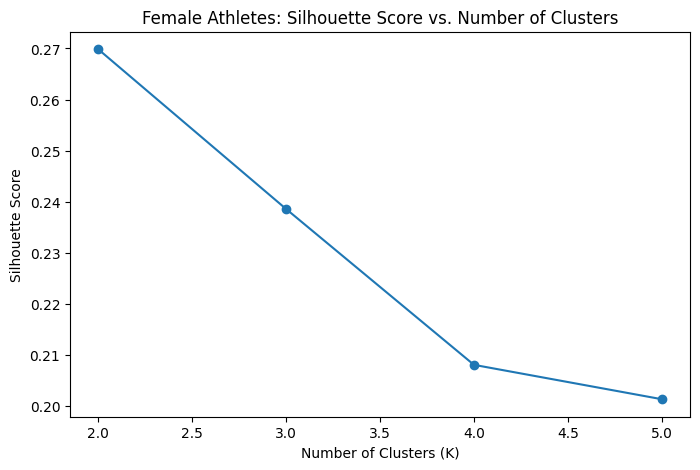

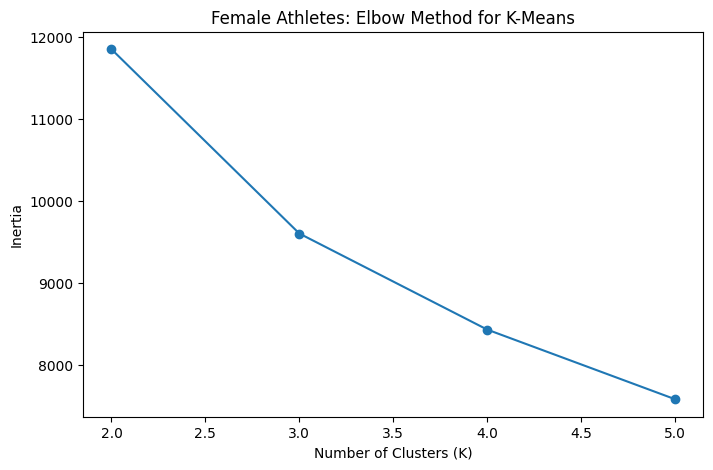

Final K chosen (based on elbow method): 3
Cluster centers shape: (3, 15)

=== Cluster Sizes ===
Cluster
0    1646
1    1710
2    1459
Name: count, dtype: int64

=== Cluster Means (Numeric Features) ===
               Age      Height     Weight
Cluster                                  
0        20.148238  165.276428  53.607837
1        24.852047  177.064912  70.143275
2        28.882111  166.196025  59.612406

=== Cluster Std Dev (Numeric Features) ===
              Age    Height    Weight
Cluster                              
0        2.723737  5.712527  6.249869
1        3.920477  5.204074  5.705361
2        3.402747  5.043564  5.732764

=== Top Sports per Cluster ===

Female Cluster 0:
Sport
Rhythmic Gymnastics    491
Diving                 176
Swimming               137
Table Tennis            93
Taekwondo               88
Archery                 79
Tennis                  74
Badminton               69
Softball                63
Triathlon               59
Name: count, dtype: int64



In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------
# Make a fresh copy and keep only FEMALE athletes
# -----------------------------
df_female = df.copy()
df_female = df_female[df_female["Sex"] == "F"].copy()

print("Female shape (Athletics INCLUDED):", df_female.shape)

# -----------------------------
# Remove outliers from numeric columns using IQR
# -----------------------------
def remove_outliers_iqr(data, cols):
    cleaned = data.copy()
    for col in cols:
        Q1 = cleaned[col].quantile(0.25)
        Q3 = cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        cleaned = cleaned[(cleaned[col] >= lower) & (cleaned[col] <= upper)]
    return cleaned

df_female = remove_outliers_iqr(df_female, ["Age", "Height", "Weight"])

print("Female shape after outlier removal:", df_female.shape)

# -----------------------------
# Use feature set for clustering
# Removed Season because only Summer sports are used
# -----------------------------
numeric_features_female = ["Age", "Height", "Weight"]
categorical_features_female = ["Sport"]

df_female = df_female[numeric_features_female + categorical_features_female].copy()

# -----------------------------
# Preprocess
# -----------------------------
preprocessor_female = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_female),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_female)
    ]
)

X_processed_female = preprocessor_female.fit_transform(df_female)

print("Female processed shape:", X_processed_female.shape)

# -----------------------------
# Dimensionality reduction
# -----------------------------
svd_female = TruncatedSVD(n_components=15, random_state=42)
X_reduced_female = svd_female.fit_transform(X_processed_female)

print("Female reduced shape:", X_reduced_female.shape)

# -----------------------------
# Try several K values (for plots only)
# -----------------------------
k_values = range(2, 6)
silhouette_scores_female = []
inertias_female = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    cluster_labels = kmeans.fit_predict(X_reduced_female)

    silhouette_avg = silhouette_score(
        X_reduced_female,
        cluster_labels,
        sample_size=min(10000, len(df_female)),
        random_state=42
    )

    silhouette_scores_female.append(silhouette_avg)
    inertias_female.append(kmeans.inertia_)

    print(f"[Female] K = {k}")
    print(f"[Female] Silhouette Score = {silhouette_avg:.4f}")
    print(f"[Female] Inertia = {kmeans.inertia_:.4f}")
    print("-" * 40)

# -----------------------------
# Plot silhouette score
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouette_scores_female, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Female Athletes: Silhouette Score vs. Number of Clusters")
plt.show()

# -----------------------------
# Plot elbow method
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias_female, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Female Athletes: Elbow Method for K-Means")
plt.show()

# -----------------------------
# K = 3 (based on elbow method)
# -----------------------------
best_k_female = 3
print(f"Final K chosen (based on elbow method): {best_k_female}")

# -----------------------------
# Fit final K-Means
# -----------------------------
kmeans_final_female = KMeans(n_clusters=best_k_female, random_state=42, n_init=20)
final_labels_female = kmeans_final_female.fit_predict(X_reduced_female)

df_female["Cluster"] = final_labels_female

# -----------------------------
# Results
# -----------------------------
print("Cluster centers shape:", kmeans_final_female.cluster_centers_.shape)

print("\n=== Cluster Sizes ===")
print(df_female["Cluster"].value_counts().sort_index())

print("\n=== Cluster Means (Numeric Features) ===")
print(df_female.groupby("Cluster")[["Age", "Height", "Weight"]].mean())

print("\n=== Cluster Std Dev (Numeric Features) ===")
print(df_female.groupby("Cluster")[["Age", "Height", "Weight"]].std())

print("\n=== Top Sports per Cluster ===")
for cluster in sorted(df_female["Cluster"].unique()):
    print(f"\nFemale Cluster {cluster}:")
    print(df_female[df_female["Cluster"] == cluster]["Sport"].value_counts().head(10))



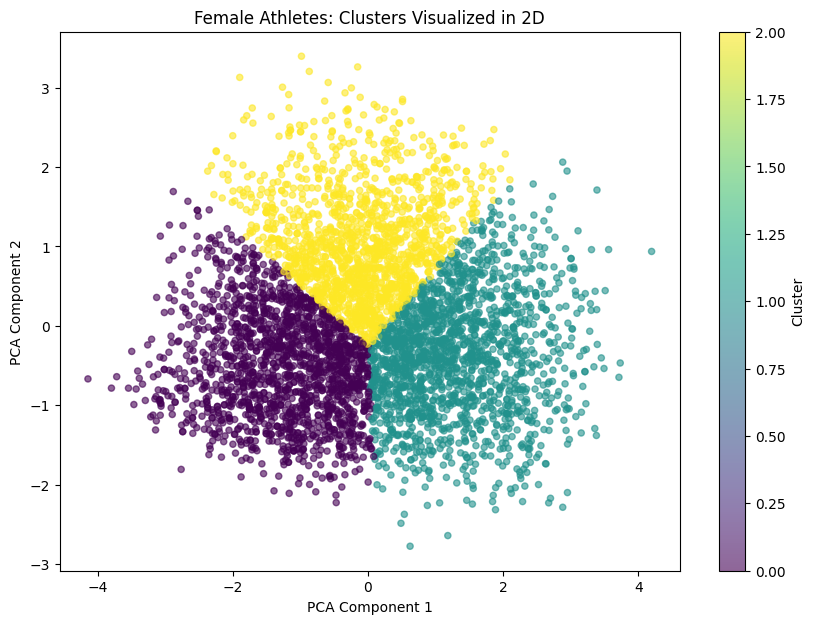

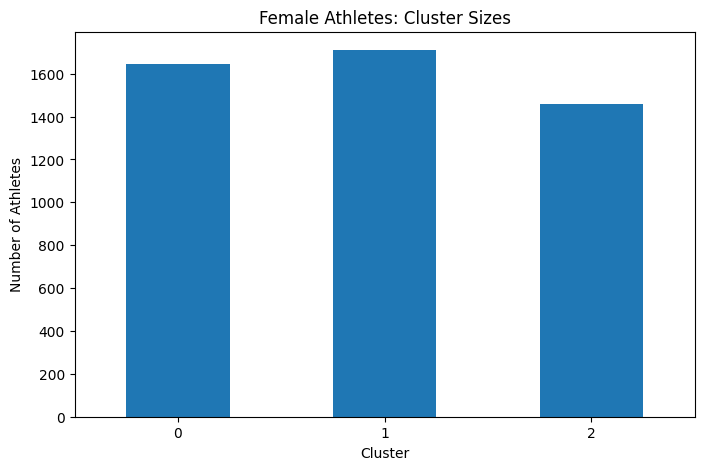

<Figure size 800x500 with 0 Axes>

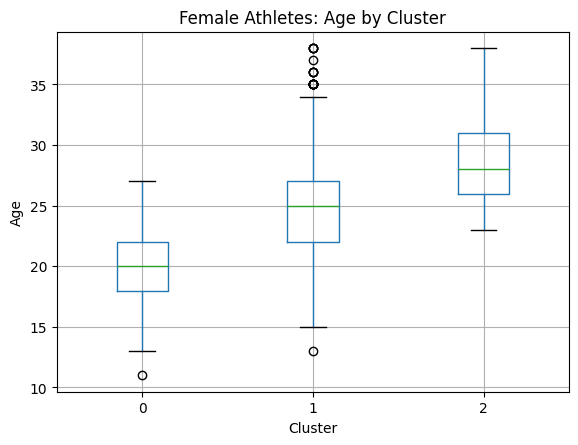

<Figure size 800x500 with 0 Axes>

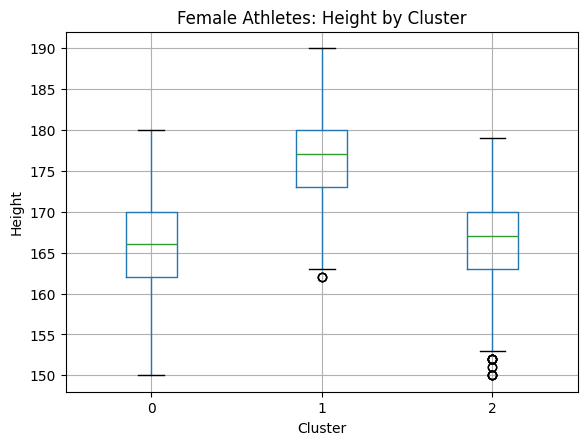

<Figure size 800x500 with 0 Axes>

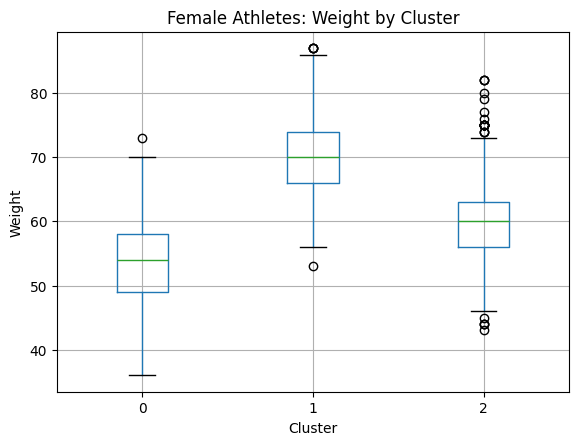

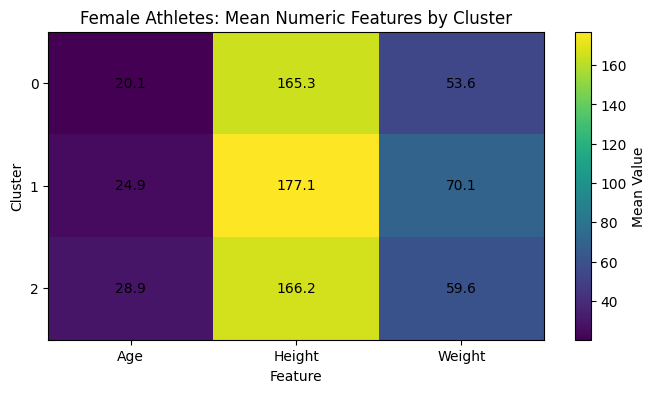

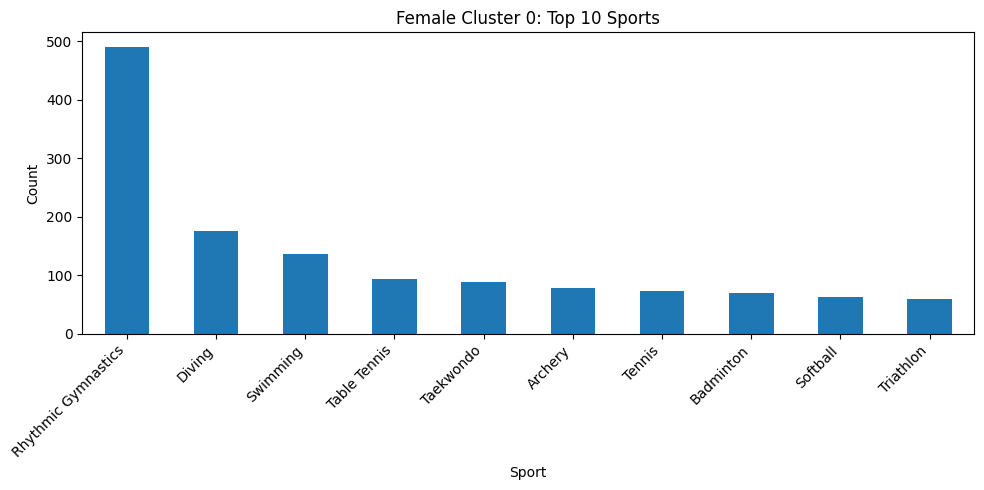

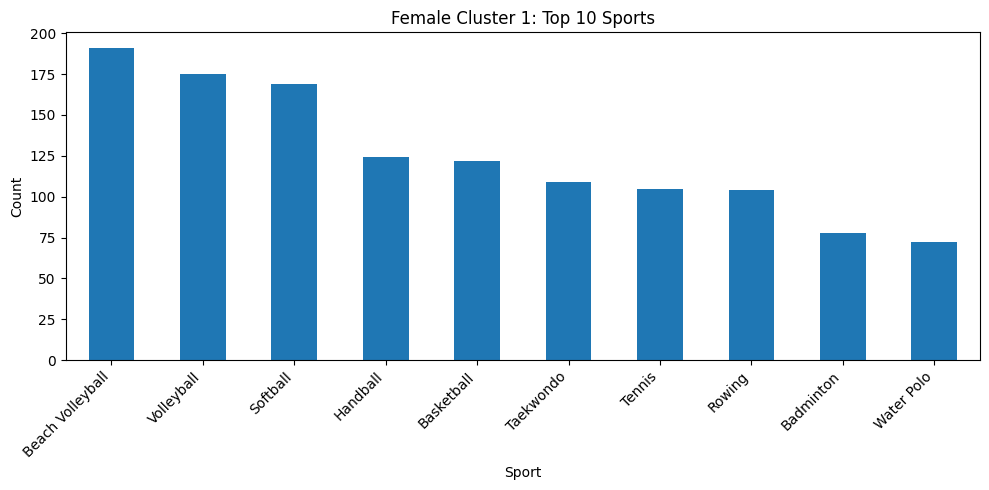

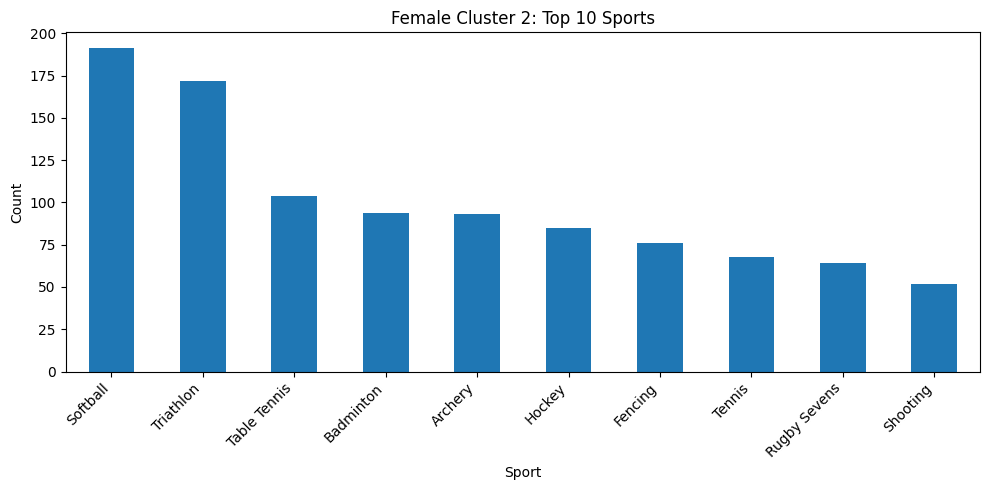

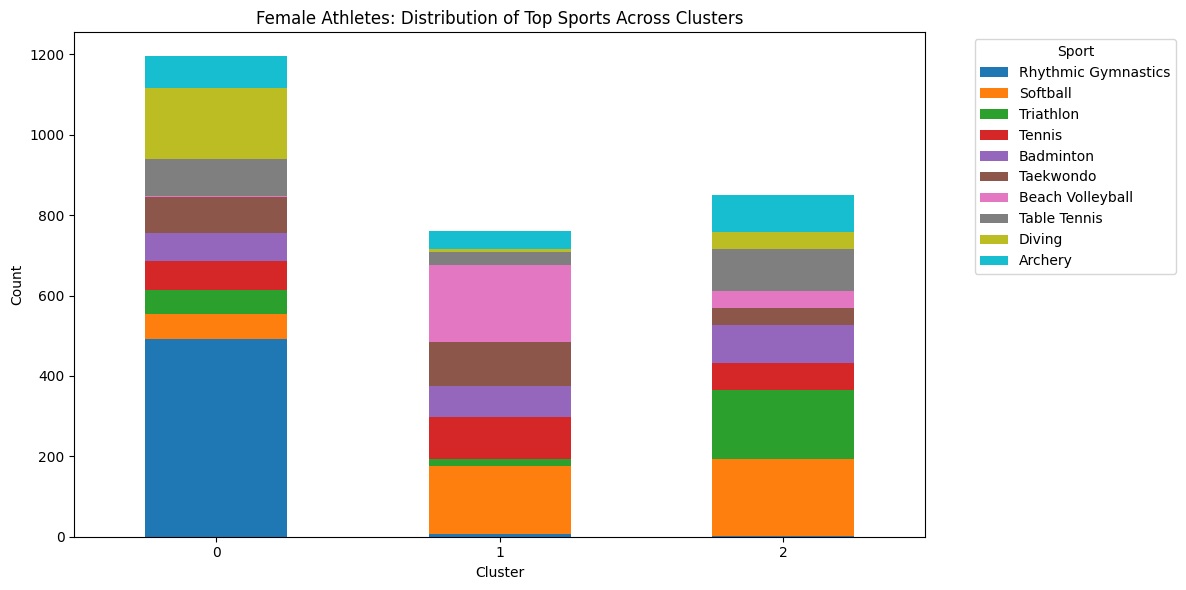

In [ ]:
# -----------------------------
# VISUALIZATIONS FOR FEMALE K-MEANS CLUSTERS
# -----------------------------

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# 1. PCA scatter plot of clusters
# -----------------------------
pca_female = PCA(n_components=2, random_state=42)
X_pca_female = pca_female.fit_transform(X_reduced_female)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca_female[:, 0],
    X_pca_female[:, 1],
    c=df_female["Cluster"],
    alpha=0.6,
    s=20
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Female Athletes: Clusters Visualized in 2D")
plt.colorbar(scatter, label="Cluster")
plt.show()

# -----------------------------
# 2. Cluster size bar chart
# -----------------------------
cluster_counts_female = df_female["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
cluster_counts_female.plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Number of Athletes")
plt.title("Female Athletes: Cluster Sizes")
plt.xticks(rotation=0)
plt.show()

# -----------------------------
# 3. Boxplots for Age, Height, and Weight
# -----------------------------
numeric_cols = ["Age", "Height", "Weight"]

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    df_female.boxplot(column=col, by="Cluster")
    plt.title(f"Female Athletes: {col} by Cluster")
    plt.suptitle("")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.show()

# -----------------------------
# 4. Heatmap of cluster means
# -----------------------------
cluster_means_female = df_female.groupby("Cluster")[["Age", "Height", "Weight"]].mean()

plt.figure(figsize=(8, 4))
plt.imshow(cluster_means_female, aspect="auto")
plt.colorbar(label="Mean Value")
plt.xticks(range(len(cluster_means_female.columns)), cluster_means_female.columns)
plt.yticks(range(len(cluster_means_female.index)), cluster_means_female.index)
plt.title("Female Athletes: Mean Numeric Features by Cluster")

for i in range(cluster_means_female.shape[0]):
    for j in range(cluster_means_female.shape[1]):
        plt.text(j, i, f"{cluster_means_female.iloc[i, j]:.1f}",
                 ha="center", va="center")

plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.show()

# -----------------------------
# 5. Top 10 sports in each cluster
# -----------------------------
for cluster in sorted(df_female["Cluster"].unique()):
    top_sports = (
        df_female[df_female["Cluster"] == cluster]["Sport"]
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(10, 5))
    top_sports.plot(kind="bar")
    plt.title(f"Female Cluster {cluster}: Top 10 Sports")
    plt.xlabel("Sport")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 6. Stacked bar chart of top sports across clusters
# -----------------------------
top_sports_overall = df_female["Sport"].value_counts().head(10).index

sport_cluster_table = pd.crosstab(
    df_female["Cluster"],
    df_female["Sport"]
)[top_sports_overall]

sport_cluster_table.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)
plt.title("Female Athletes: Distribution of Top Sports Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Sport", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Heirarcheal Clustering

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


#Z = linkage(X_reduced, method='ward')

df_sample = df.sample(n=5000, random_state=42)  # try 2000–5000

# Re-run preprocessing on sample
X_processed_sample = preprocessor.fit_transform(df_sample)
X_reduced_sample = svd.fit_transform(X_processed_sample)

Z = linkage(X_reduced_sample, method='ward')

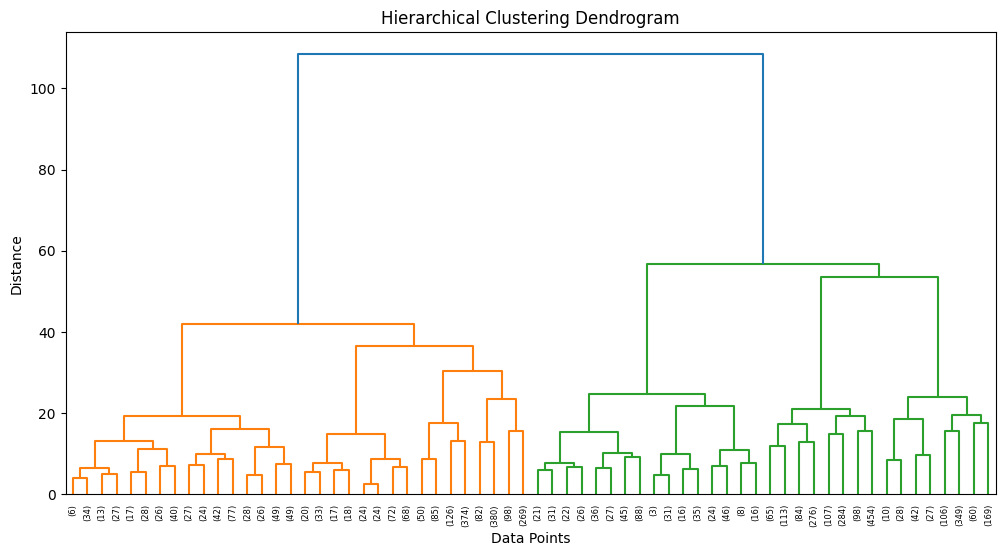

In [ ]:
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # limits size so it’s readable
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [ ]:
# --- STEP 1: SAMPLE DATA (CRITICAL) ---
df_sample = df.sample(n=3000, random_state=42)  # try 2000–5000 max

# --- STEP 2: REPROCESS SAMPLE ---
X_processed_sample = preprocessor.fit_transform(df_sample)

# Reduce dimensions MORE to make clustering lighter
from sklearn.decomposition import TruncatedSVD
svd_small = TruncatedSVD(n_components=10, random_state=42)
X_reduced_sample = svd_small.fit_transform(X_processed_sample)

# --- STEP 3: HIERARCHICAL CLUSTERING (SAFE) ---
from sklearn.cluster import AgglomerativeClustering

k = 8
model = AgglomerativeClustering(n_clusters=k, linkage='ward')
df_sample['Cluster'] = model.fit_predict(X_reduced_sample)

# --- STEP 4: ANALYZE SPORTS IN CLUSTERS ---
print("\n=== Sport Counts Per Cluster ===")
print(df_sample.groupby('Cluster')['Sport'].value_counts())

print("\n=== Sport Percentages Per Cluster ===")
print(
    df_sample.groupby('Cluster')['Sport']
    .value_counts(normalize=True)
    .rename("Percentage")
)

print("\n=== Top 3 Sports Per Cluster ===")
print(
    df_sample.groupby('Cluster')['Sport']
    .value_counts()
    .groupby(level=0)
    .head(3)
)

# --- STEP 5: CLUSTER CHARACTERISTICS ---
print("\n=== Cluster Averages (Age, Height, Weight) ===")
print(df_sample.groupby('Cluster')[["Age", "Height", "Weight"]].mean())


=== Sport Counts Per Cluster ===
Cluster  Sport            
0        Beach Volleyball     72
         Rowing               60
         Basketball           51
         Volleyball           43
         Handball             40
                              ..
7        Fencing               1
         Hockey                1
         Modern Pentathlon     1
         Sailing               1
         Table Tennis          1
Name: count, Length: 189, dtype: int64

=== Sport Percentages Per Cluster ===
Cluster  Sport            
0        Beach Volleyball     0.128801
         Rowing               0.107335
         Basketball           0.091234
         Volleyball           0.076923
         Handball             0.071556
                                ...   
7        Fencing              0.006098
         Hockey               0.006098
         Modern Pentathlon    0.006098
         Sailing              0.006098
         Table Tennis         0.006098
Name: Percentage, Length: 189, dtype: floa

Graph distances to select right eps value for dbscan

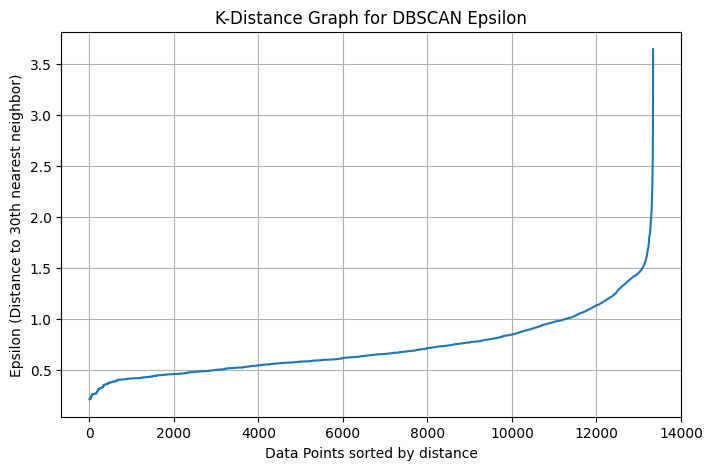

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=30)
neighbors_fit = neighbors.fit(X_reduced)
distances, indices = neighbors_fit.kneighbors(X_reduced)

distances = np.sort(distances[:, 29], axis=0)
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title('K-Distance Graph for DBSCAN Epsilon')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon (Distance to 30th nearest neighbor)')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.0, min_samples=50)
labels = dbscan.fit_predict(X_reduced)
df['D_Cluster'] = labels

archetypes = df.groupby('D_Cluster').agg({
    'Age': 'mean',
    'Height': 'mean',
    'Weight': 'mean',
    'Sport': lambda x: x.value_counts().index[0],
    'Sex': lambda x: x.value_counts().index[0]
}).round(1)

archetypes['Count'] = df['D_Cluster'].value_counts()

print(archetypes.sort_index())

            Age  Height  Weight                Sport Sex  Count
D_Cluster                                                      
-1         31.5   174.7    81.3             Shooting   M    906
 0         25.7   180.4    78.0             Baseball   M   7612
 1         24.2   170.3    61.5  Rhythmic Gymnastics   F   4574
 2         30.0   193.1    89.4     Beach Volleyball   M    250


In [ ]:
#top 3 sports by cluster
top_sports_data = {}
for cluster_id, group in df.groupby('D_Cluster'):
    top_sports_data[cluster_id] = group['Sport'].value_counts().head(3).to_dict()

dbscan_top_sports = pd.Series(top_sports_data)

print("=== Top 3 Sports Per DBSCAN Cluster ===")
for cluster_id, sports_dict in dbscan_top_sports.items():
    print(f"\nCluster {cluster_id}:")
    for sport, count in sports_dict.items():
        print(f"  - {sport}: {count}")

=== Top 3 Sports Per DBSCAN Cluster ===

Cluster -1:
  - Shooting: 147
  - Weightlifting: 114
  - Archery: 90

Cluster 0:
  - Baseball: 495
  - Boxing: 476
  - Wrestling: 430

Cluster 1:
  - Rhythmic Gymnastics: 500
  - Softball: 426
  - Triathlon: 249

Cluster 2:
  - Beach Volleyball: 248
  - Golf: 2


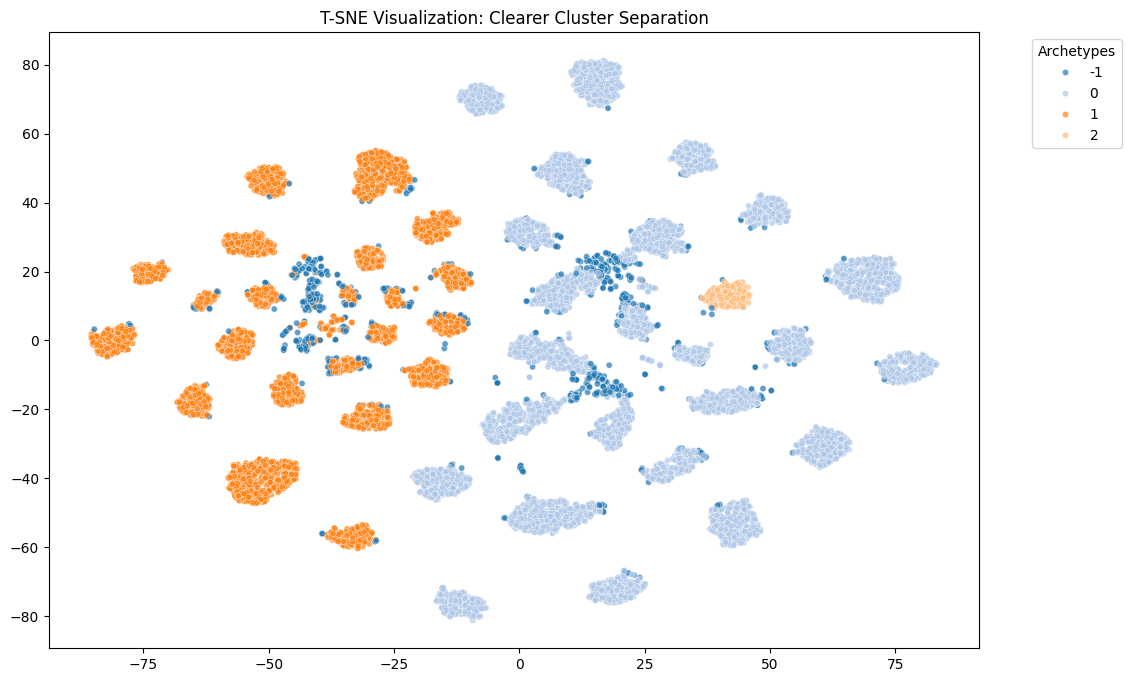

In [ ]:
from sklearn.manifold import TSNE
import seaborn as sns

tsne = TSNE(n_components=2, perplexity=80, random_state=42, init='pca', learning_rate='auto')

X_tsne = tsne.fit_transform(X_reduced)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=labels, palette='tab20',
    s=20, alpha=0.7, legend='full'
)
plt.title("T-SNE Visualization: Clearer Cluster Separation")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Archetypes")
plt.show()

In [ ]:
mask = labels != -1
X_clustered = X_reduced[mask]
labels_clustered = labels[mask]

unique_clusters = len(np.unique(labels_clustered))

if unique_clusters > 1:
    sample_size = min(5000, len(X_clustered))
    idx = np.random.choice(len(X_clustered), sample_size, replace=False)
    random_labels = np.random.randint(0, unique_clusters, size=sample_size)
    score_actual = silhouette_score(X_clustered[idx], labels_clustered[idx])
    score_baseline = silhouette_score(X_clustered[idx], random_labels)

print(f"DBSCAN Silhouette Score: {score_actual:.4f}")

DBSCAN Silhouette Score: 0.1098


In [ ]:
dbscan = DBSCAN(eps=.85, min_samples=50)
labels = dbscan.fit_predict(X_reduced)
df['D_Cluster'] = labels

archetypes = df.groupby('D_Cluster').agg({
    'Age': 'mean',
    'Height': 'mean',
    'Weight': 'mean',
    'Sport': lambda x: x.value_counts().index[0],
    'Sex': lambda x: x.value_counts().index[0]
}).round(1)

archetypes['Count'] = df['D_Cluster'].value_counts()

print(archetypes.sort_index())

            Age  Height  Weight                Sport Sex  Count
D_Cluster                                                      
-1         29.5   175.4    77.7                 Judo   F   2004
 0         23.5   179.0    76.2              Archery   M    156
 1         24.0   167.3    61.2              Archery   F    195
 2         24.6   168.9    61.9            Badminton   F    236
 3         26.1   179.5    73.8            Badminton   M    249
 4         26.0   182.6    85.7             Baseball   M    485
 5         24.9   195.4    91.1           Basketball   M    286
 6         24.4   181.9    72.7           Basketball   F    119
 7         28.3   179.0    68.4     Beach Volleyball   F    244
 8         29.9   192.8    89.1     Beach Volleyball   M    236
 9         23.1   172.0    64.0               Boxing   M    457
 10        21.5   162.2    53.7               Diving   F    222
 11        22.8   171.5    67.0               Diving   M    262
 12        26.0   180.0    74.5         

In [ ]:
#top 3 sports by cluster
top_sports_data = {}
for cluster_id, group in df.groupby('D_Cluster'):
    top_sports_data[cluster_id] = group['Sport'].value_counts().head(3).to_dict()

dbscan_top_sports = pd.Series(top_sports_data)

print("=== Top 3 Sports Per DBSCAN Cluster ===")
for cluster_id, sports_dict in dbscan_top_sports.items():
    print(f"\nCluster {cluster_id}:")
    for sport, count in sports_dict.items():
        print(f"  - {sport}: {count}")

=== Top 3 Sports Per DBSCAN Cluster ===

Cluster -1:
  - Judo: 227
  - Shooting: 205
  - Sailing: 186

Cluster 0:
  - Archery: 156

Cluster 1:
  - Archery: 195

Cluster 2:
  - Badminton: 236

Cluster 3:
  - Badminton: 249

Cluster 4:
  - Baseball: 485

Cluster 5:
  - Basketball: 286

Cluster 6:
  - Basketball: 119

Cluster 7:
  - Beach Volleyball: 244

Cluster 8:
  - Beach Volleyball: 236

Cluster 9:
  - Boxing: 457

Cluster 10:
  - Diving: 222

Cluster 11:
  - Diving: 262

Cluster 12:
  - Fencing: 316

Cluster 13:
  - Fencing: 117

Cluster 14:
  - Handball: 304

Cluster 15:
  - Handball: 174

Cluster 16:
  - Hockey: 161

Cluster 17:
  - Hockey: 320

Cluster 18:
  - Judo: 273

Cluster 19:
  - Modern Pentathlon: 396

Cluster 20:
  - Modern Pentathlon: 64

Cluster 21:
  - Rhythmic Gymnastics: 500

Cluster 22:
  - Rowing: 336

Cluster 23:
  - Rowing: 104

Cluster 24:
  - Rugby Sevens: 116

Cluster 25:
  - Rugby Sevens: 111

Cluster 26:
  - Sailing: 314

Cluster 27:
  - Shooting: 295

Clus

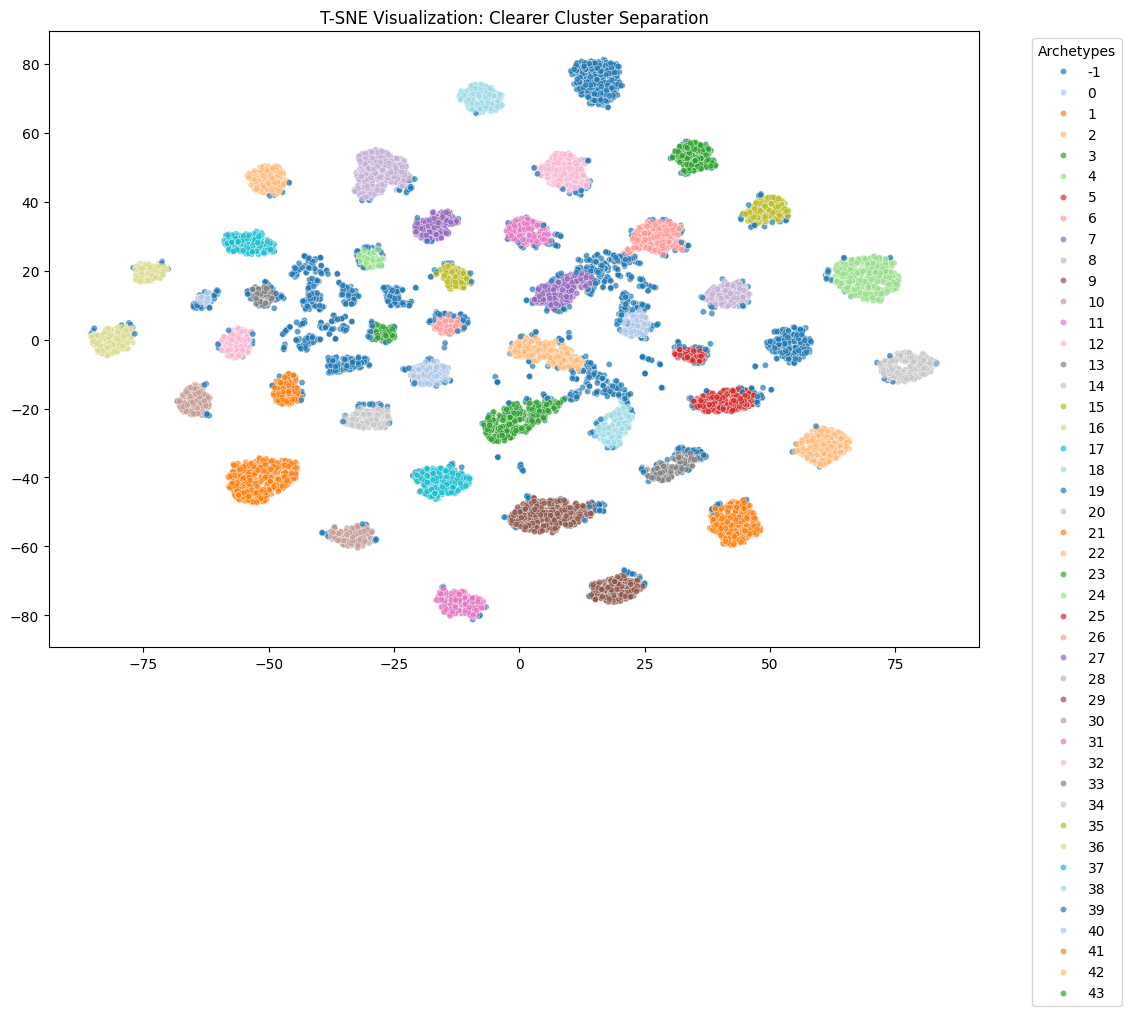

In [ ]:
from sklearn.manifold import TSNE
import seaborn as sns

tsne = TSNE(n_components=2, perplexity=80, random_state=42, init='pca', learning_rate='auto')

X_tsne = tsne.fit_transform(X_reduced)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=labels, palette='tab20',
    s=20, alpha=0.7, legend='full'
)
plt.title("T-SNE Visualization: Clearer Cluster Separation")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Archetypes")
plt.show()

In [ ]:
mask = labels != -1
X_clustered = X_reduced[mask]
labels_clustered = labels[mask]

unique_clusters = len(np.unique(labels_clustered))

if unique_clusters > 1:
    sample_size = min(5000, len(X_clustered))
    idx = np.random.choice(len(X_clustered), sample_size, replace=False)
    random_labels = np.random.randint(0, unique_clusters, size=sample_size)
    score_actual = silhouette_score(X_clustered[idx], labels_clustered[idx])
    score_baseline = silhouette_score(X_clustered[idx], random_labels)

print(f"DBSCAN Silhouette Score: {score_actual:.4f}")

DBSCAN Silhouette Score: 0.2689


In [ ]:
from scipy.cluster.hierarchy import fcluster, linkage

k_hier = 8
Z_hier = linkage(X_reduced_sample, method='ward')
hier_labels = fcluster(Z_hier, t=k_hier, criterion='maxclust')
score_hier = silhouette_score(X_reduced_sample, hier_labels)
random_labels_hier = np.random.randint(1, k_hier + 1, size=len(hier_labels))
score_baseline_hier = silhouette_score(X_reduced_sample, random_labels_hier)

print(f"Hierarchical Silhouette Score:   {score_hier:.4f}")

Hierarchical Silhouette Score:   0.1731


In [ ]:
from sklearn.metrics import silhouette_score

eval_sample_size = 5000
if len(X_reduced) > eval_sample_size:
    indices = np.random.choice(X_reduced.shape[0], eval_sample_size, replace=False)
    X_eval = X_reduced[indices]
else:
    X_eval = X_reduced

k_values = {
    "Hierarchical": 8,
    "K-Means": 3,
    "DBSCAN (3)": 3,
    "DBSCAN (43)": 43
}

print("Baseline Silhouette Scores")
baselines = {}

for name, k in k_values.items():
    random_labels = np.random.randint(0, k, size=len(X_eval))

    score = silhouette_score(X_eval, random_labels)
    baselines[name] = score

    print(f"{name:<12} (K={k:<2}): {score:.4f}")

Baseline Silhouette Scores
Hierarchical (K=8 ): -0.0158
K-Means      (K=3 ): -0.0045
DBSCAN (3)   (K=3 ): -0.0054
DBSCAN (43)  (K=43): -0.0566
